# Cricket Player Recognition System using YOLO11 Image Classification

A simple, CPU-friendly deep learning project that classifies Indian cricket players
from images using **YOLO11n-cls**.

**Steps in this notebook:**
1. Setup
2. Load & Explore Dataset
3. Basic Dataset Check
4. Split Dataset (Train / Val / Test)
5. Train YOLO11 Classifier
6. Evaluate Model
7. Run Predictions
8. Export Model
9. Simple Streamlit App

**Dataset:** 27 folders of Indian cricketers located at:
`C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset`

In [1]:
# ============================================================
# SETUP - INSTALL & IMPORT
# ============================================================

import sys, subprocess

def install_packages():
    packages = ["ultralytics", "matplotlib", "pandas", "numpy",
                "scikit-learn", "streamlit", "pillow", "onnx", "onnxruntime"]
    for pkg in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
    print("All packages installed.")

install_packages()

import os, shutil, random, time
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from ultralytics import YOLO
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup complete.")
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} (should be False - CPU only)")

All packages installed.
Setup complete.
Torch version: 2.12.1+cpu
CUDA available: False (should be False - CPU only)


## Project Setup

Set the dataset path and create simple output folders:

```
Cricket_Player_Recognition_System/
├── dataset/     (train/val/test split goes here)
├── models/      (saved model files)
├── results/     (charts, reports)
└── app/         (streamlit app)
```

In [2]:
# ============================================================
# PROJECT SETUP 
# ============================================================

RAW_DATASET_DIR = Path(r"C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset")

PROJECT_ROOT = Path.cwd() / "Cricket_Player_Recognition_System"
DATASET_DIR = PROJECT_ROOT / "dataset"
MODELS_DIR  = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
APP_DIR     = PROJECT_ROOT / "app"

for d in [PROJECT_ROOT, DATASET_DIR, MODELS_DIR, RESULTS_DIR, APP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Auto-detects all folders currently in RAW_DATASET_DIR - should be your 10 selected players
CLASS_NAMES = sorted([d.name for d in RAW_DATASET_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Project folder created at: {PROJECT_ROOT.resolve()}")
print(f"Found {NUM_CLASSES} player classes:")
print(CLASS_NAMES)

# Quick per-class image count check, so you can spot any folder that's too thin before training
for cls in CLASS_NAMES:
    count = len([f for f in (RAW_DATASET_DIR / cls).iterdir() if f.is_file()])
    flag = "  <-- LOW COUNT, worth checking" if count < 40 else ""
    print(f"  {cls:20s}: {count} images{flag}")

Project folder created at: C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System
Found 10 player classes:
['Gautam Gambhir', 'Harbhajan Singh', 'Hardik Pandya', 'MS Dhoni', 'Rahul Dravid', 'Rohit Sharma', 'Sachin Tendulkar', 'Shikhar Dhawan', 'Virat Kohli', 'Yuvraj Singh']
  Gautam Gambhir      : 60 images
  Harbhajan Singh     : 62 images
  Hardik Pandya       : 63 images
  MS Dhoni            : 62 images
  Rahul Dravid        : 62 images
  Rohit Sharma        : 65 images
  Sachin Tendulkar    : 60 images
  Shikhar Dhawan      : 67 images
  Virat Kohli         : 70 images
  Yuvraj Singh        : 62 images


## Explore Dataset

Count how many images each player has, and show one sample image per player.

Total images: 633
Average images per player: 63.3


,Player,ImageCount
0,Virat Kohli,70
1,Shikhar Dhawan,67
2,Rohit Sharma,65
3,Hardik Pandya,63
4,Rahul Dravid,62
5,Harbhajan Singh,62
6,Yuvraj Singh,62
7,MS Dhoni,62
8,Gautam Gambhir,60
9,Sachin Tendulkar,60


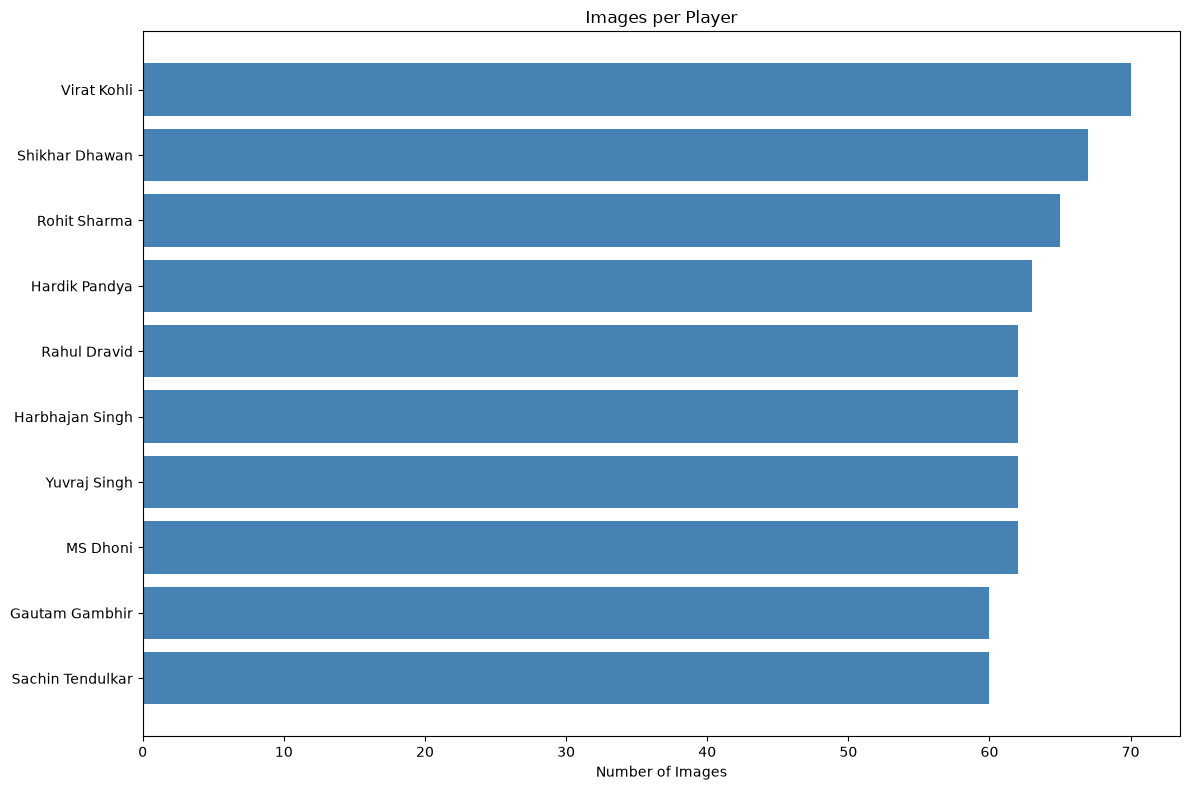

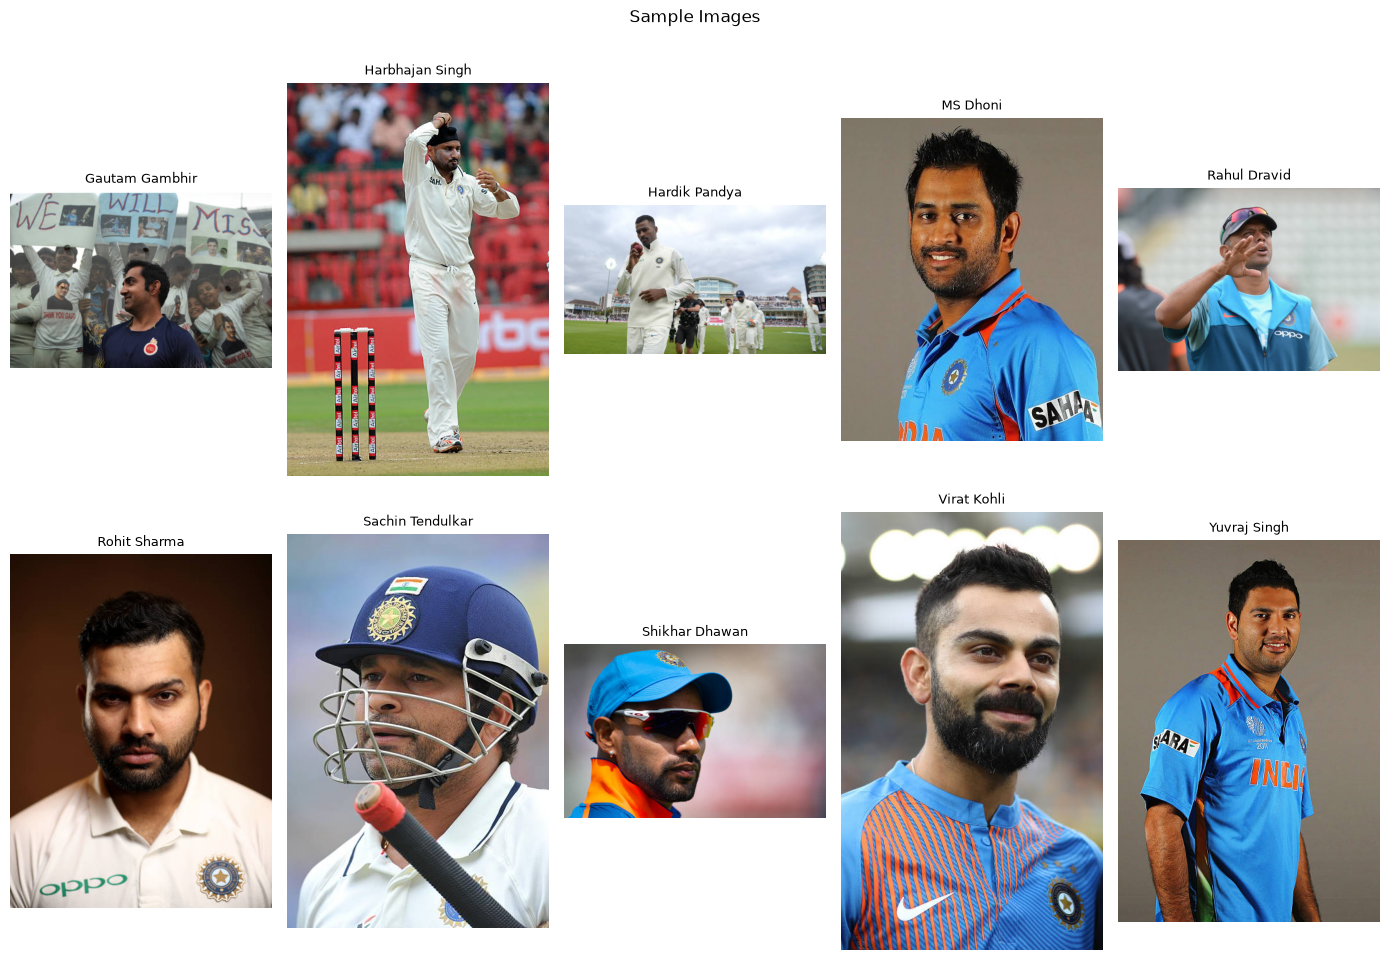

In [9]:
# ============================================================
#  EXPLORE DATASET
# ============================================================

counts = {}
for cls in CLASS_NAMES:
    class_dir = RAW_DATASET_DIR / cls
    num_files = len([f for f in class_dir.iterdir() if f.is_file()])
    counts[cls] = num_files

df_counts = pd.DataFrame(list(counts.items()), columns=["Player", "ImageCount"])
df_counts = df_counts.sort_values("ImageCount", ascending=False).reset_index(drop=True)

print(f"Total images: {df_counts['ImageCount'].sum()}")
print(f"Average images per player: {df_counts['ImageCount'].mean():.1f}")
display(df_counts)

# Simple bar chart
plt.figure(figsize=(12, 8))
plt.barh(df_counts["Player"], df_counts["ImageCount"], color="steelblue")
plt.xlabel("Number of Images")
plt.title("Images per Player")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "images_per_class.png")
plt.show()



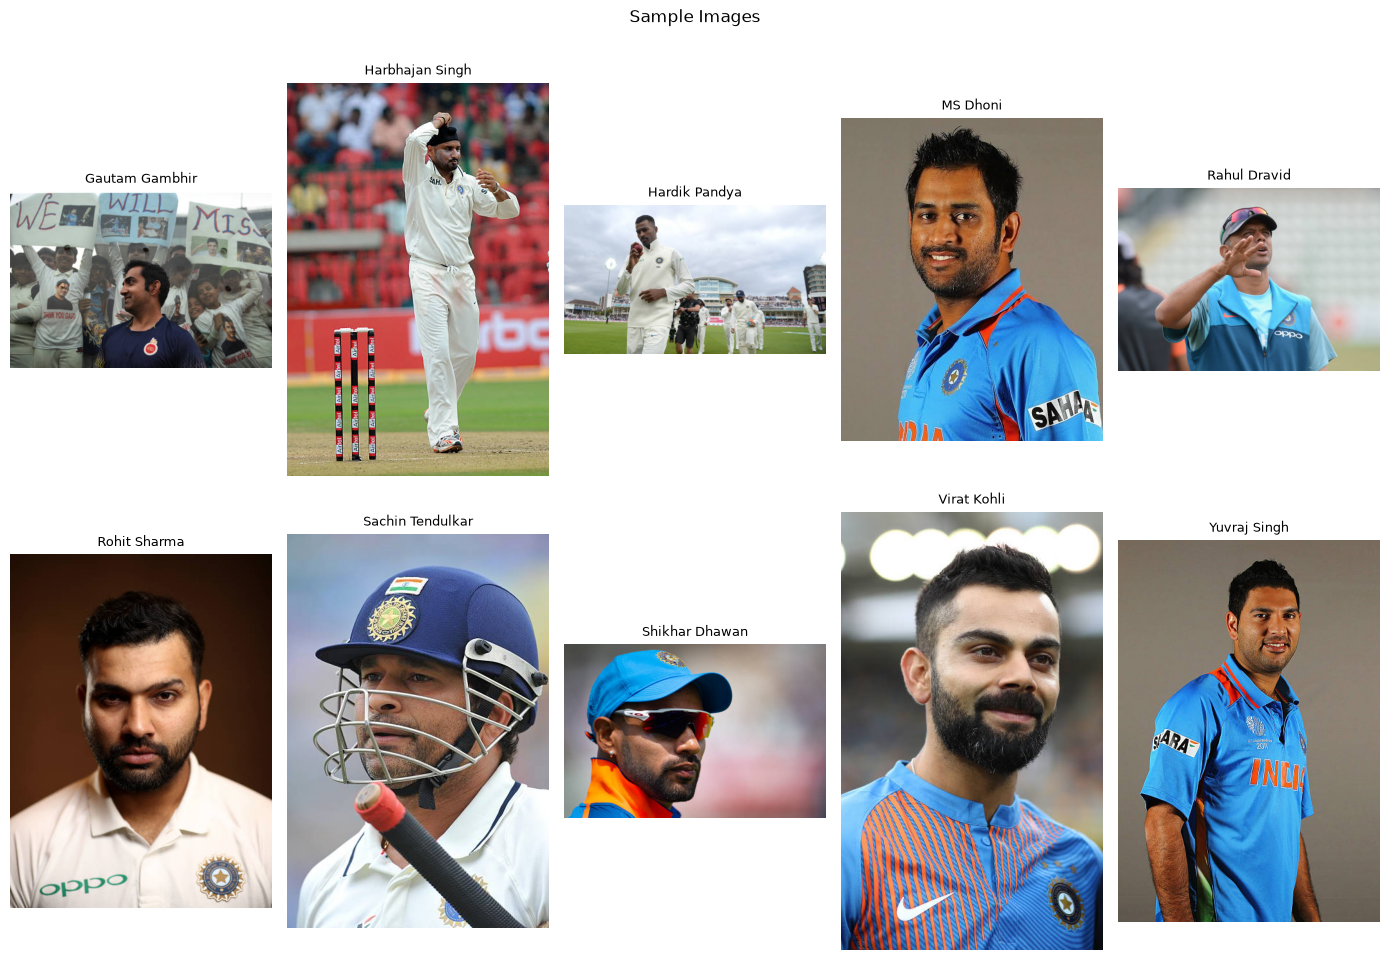

In [10]:
# Sample images (one per player, first 12 players)
fig, axes = plt.subplots(2, 5, figsize=(14, 10))
for ax, cls in zip(axes.flatten(), CLASS_NAMES[:12]):
    class_dir = RAW_DATASET_DIR / cls
    files = [f for f in class_dir.iterdir() if f.is_file()]
    if files:
        img = Image.open(files[0]).convert("RGB")
        ax.imshow(img)
        ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images.png")
plt.show()

df_counts.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)

## Basic Dataset Check

A simple check to make sure every image can actually be opened. Anything broken is
skipped and reported — this keeps the cleaning step easy to understand.

In [11]:
# ============================================================
#  BASIC DATASET CHECK
# ============================================================

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

bad_files = []
good_count = 0

for cls in CLASS_NAMES:
    class_dir = RAW_DATASET_DIR / cls
    for fpath in class_dir.iterdir():
        if not fpath.is_file():
            continue
        if fpath.suffix.lower() not in VALID_EXTENSIONS:
            bad_files.append(str(fpath))
            continue
        try:
            with Image.open(fpath) as img:
                img.verify()
            good_count += 1
        except Exception:
            bad_files.append(str(fpath))

print(f"Good images : {good_count}")
print(f"Bad/broken images found: {len(bad_files)}")
if bad_files:
    print("These files will be skipped during splitting:")
    for f in bad_files[:10]:
        print(f"  - {f}")

pd.DataFrame({"bad_file": bad_files}).to_csv(RESULTS_DIR / "bad_files.csv", index=False)

Good images : 633
Bad/broken images found: 0


## Face Detection & Cropping

Detects the face in each image and crops around it, removing background, jerseys,
crowds, and text overlays. This gives the model a much cleaner signal to learn from,
since it now focuses only on facial features instead of unrelated visual noise.

In [12]:
# ============================================================
# FACE DETECTION & CROPPING
# ============================================================
import cv2

# Fallback in case Basic Dataset Check cell wasn't run first
if "bad_files_set" not in dir():
    print("Note: bad_files_set not found - skipping the bad-file filter (run Basic Dataset Check for full cleaning).")
    bad_files_set = set()

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

FACE_CROP_DIR = PROJECT_ROOT / "dataset_faces"
if FACE_CROP_DIR.exists():
    shutil.rmtree(FACE_CROP_DIR)
FACE_CROP_DIR.mkdir(parents=True, exist_ok=True)

PADDING = 0.35

cropped_count = 0
no_face_count = 0
no_face_files = []

for cls in CLASS_NAMES:
    class_dir = RAW_DATASET_DIR / cls
    out_dir = FACE_CROP_DIR / cls
    out_dir.mkdir(parents=True, exist_ok=True)

    for fpath in class_dir.iterdir():
        if not fpath.is_file() or str(fpath) in bad_files_set:
            continue

        img = cv2.imread(str(fpath))
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

        if len(faces) == 0:
            no_face_count += 1
            no_face_files.append(str(fpath))
            shutil.copy2(fpath, out_dir / fpath.name)
            continue

        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        pad_w, pad_h = int(w * PADDING), int(h * PADDING)
        x1 = max(0, x - pad_w)
        y1 = max(0, y - pad_h)
        x2 = min(img.shape[1], x + w + pad_w)
        y2 = min(img.shape[0], y + h + pad_h)

        face_crop = img[y1:y2, x1:x2]
        cv2.imwrite(str(out_dir / fpath.name), face_crop)
        cropped_count += 1

print(f"Faces cropped successfully : {cropped_count}")
print(f"No face detected (kept original): {no_face_count}")
print(f"Face-cropped dataset saved to: {FACE_CROP_DIR}")

if no_face_files:
    print("\nExamples where no face was detected (worth checking manually):")
    for f in no_face_files[:10]:
        print(f"  - {f}")

Faces cropped successfully : 470
No face detected (kept original): 163
Face-cropped dataset saved to: C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\dataset_faces

Examples where no face was detected (worth checking manually):
  - C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset\Gautam Gambhir\gettyimages-1070640768-612x612.jpg
  - C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset\Gautam Gambhir\gettyimages-2190874030-612x612.jpg
  - C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset\Gautam Gambhir\gettyimages-2191257003-612x612.jpg
  - C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset\Gautam Gambhir\gettyimages-2201240752-612x612.jpg
  - C:\Users\Test1\Pictures\Cricket Player Recognition System\Indian Cricketers Image_dataset\Gautam Gambhir\gettyimag

## Split Dataset

Split images into train (70%), validation (15%), and test (15%) sets, arranged into
the folder format YOLO expects:

```
dataset/
├── train/<player_name>/*.jpg
├── val/<player_name>/*.jpg
└── test/<player_name>/*.jpg
```

In [13]:
# ============================================================
# CELL 10: SPLIT DATASET
# ============================================================

bad_files_set = set(bad_files)

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
for split in ["train", "val", "test"]:
    (DATASET_DIR / split).mkdir(parents=True, exist_ok=True)

rng = random.Random(SEED)
split_counts = []

for cls in CLASS_NAMES:
    class_dir = FACE_CROP_DIR / cls
    files = [f for f in class_dir.iterdir() if f.is_file() and str(f) not in bad_files_set]
    rng.shuffle(files)

    n = len(files)
    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for split_name, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        out_dir = DATASET_DIR / split_name / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            shutil.copy2(f, out_dir / f.name)

    split_counts.append({"Player": cls, "train": len(train_files), "val": len(val_files), "test": len(test_files)})

df_split = pd.DataFrame(split_counts)
df_split["total"] = df_split["train"] + df_split["val"] + df_split["test"]

print("Split complete.")
display(df_split)
print(f"\nTotal train: {df_split['train'].sum()}  |  val: {df_split['val'].sum()}  |  test: {df_split['test'].sum()}")

df_split.to_csv(RESULTS_DIR / "split_summary.csv", index=False)

Split complete.


,Player,train,val,test,total
0,Gautam Gambhir,42,9,9,60
1,Harbhajan Singh,43,9,10,62
2,Hardik Pandya,44,9,10,63
3,MS Dhoni,43,9,10,62
4,Rahul Dravid,43,9,10,62
5,Rohit Sharma,45,9,11,65
6,Sachin Tendulkar,42,9,9,60
7,Shikhar Dhawan,46,10,11,67
8,Virat Kohli,49,10,11,70
9,Yuvraj Singh,43,9,10,62



Total train: 440  |  val: 92  |  test: 101


## Train YOLO11 Classifier (CPU)

Trains **YOLO11n-cls**, the smallest/fastest YOLO classification model, using
simple settings suited to CPU-only training.

In [14]:
# ============================================================
#  TRAIN MODEL 
# ============================================================

model = YOLO("yolo11n-cls.pt")

results = model.train(
    data=str(DATASET_DIR),
    epochs=20,          # reduced from 30 - val loss plateaus by ~epoch 20 on this dataset size
    batch=32,
    imgsz=IMG_SIZE,
    device="cpu",
    seed=SEED,
    patience=8,
    dropout=0.2,         # reduces overfitting on the smaller dataset
    project=str(RESULTS_DIR),
    name="cricket_model_v2",
    exist_ok=True
)

RUN_DIR = RESULTS_DIR / "cricket_model_v2"
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

shutil.copy2(BEST_PT, MODELS_DIR / "best.pt")
shutil.copy2(LAST_PT, MODELS_DIR / "last.pt")

print("Training complete.")
print(f"Best model saved to: {MODELS_DIR / 'best.pt'}")

Ultralytics 8.4.84  Python-3.13.9 torch-2.12.1+cpu CPU (12th Gen Intel Core i9-12900)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scal

## Evaluate Model

Check how well the model performs on the test set: accuracy, precision, recall,
F1 score, and a confusion matrix.

Accuracy : 0.8317
Precision: 0.8333
Recall   : 0.8317
F1 Score : 0.8300


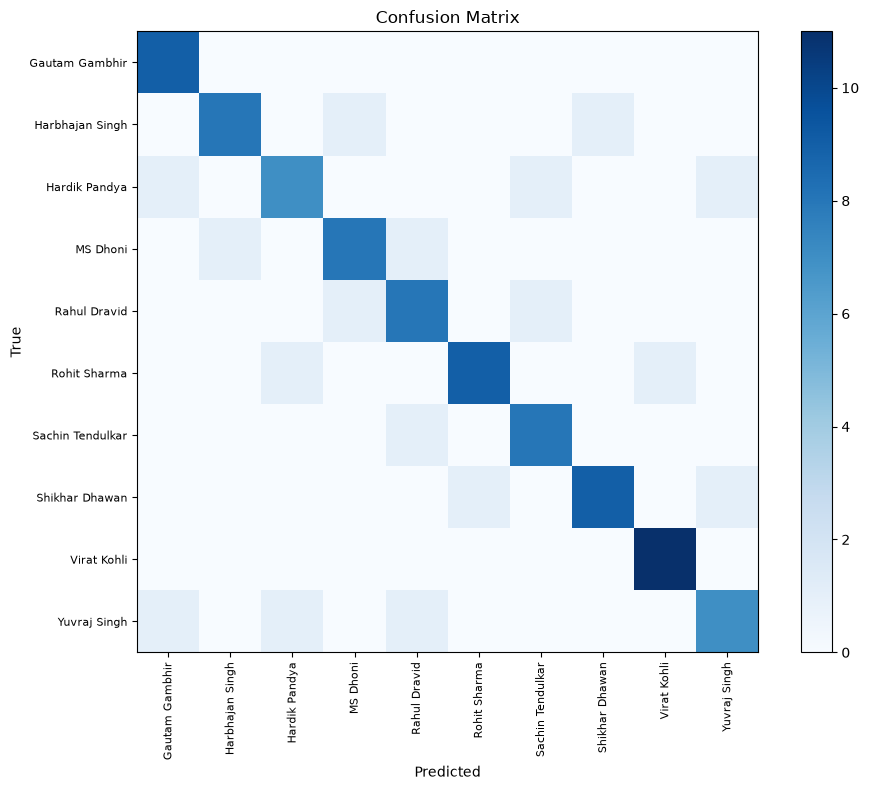

                  precision    recall  f1-score   support

  Gautam Gambhir       0.82      1.00      0.90         9
 Harbhajan Singh       0.89      0.80      0.84        10
   Hardik Pandya       0.78      0.70      0.74        10
        MS Dhoni       0.80      0.80      0.80        10
    Rahul Dravid       0.73      0.80      0.76        10
    Rohit Sharma       0.90      0.82      0.86        11
Sachin Tendulkar       0.80      0.89      0.84         9
  Shikhar Dhawan       0.90      0.82      0.86        11
     Virat Kohli       0.92      1.00      0.96        11
    Yuvraj Singh       0.78      0.70      0.74        10

        accuracy                           0.83       101
       macro avg       0.83      0.83      0.83       101
    weighted avg       0.83      0.83      0.83       101



In [18]:
# ============================================================
# EVALUATE MODEL
# ============================================================

best_model = YOLO(str(MODELS_DIR / "best.pt"))

test_dir = DATASET_DIR / "test"
class_to_idx = {name: idx for idx, name in enumerate(sorted(best_model.names.values()))}

y_true, y_pred = [], []

for cls in CLASS_NAMES:
    class_dir = test_dir / cls
    if not class_dir.exists():
        continue
    for fpath in class_dir.iterdir():
        if not fpath.is_file():
            continue
        result = best_model.predict(source=str(fpath), device="cpu", imgsz=IMG_SIZE, verbose=False)[0]
        pred_idx = int(result.probs.top1)
        y_true.append(class_to_idx[cls])
        y_pred.append(pred_idx)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion matrix
labels = sorted(best_model.names.values())
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), labels, rotation=90, fontsize=8)
plt.yticks(range(NUM_CLASSES), labels, fontsize=8)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png")
plt.show()

report_text = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
print(report_text)
with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(report_text)

## Run Predictions

Test the trained model on a single image and print the top prediction with confidence,
plus the top-5 most likely players for that image.

Image: C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\dataset\test\Gautam Gambhir\gettyimages-107780130-612x612.jpg
Predicted: Gautam Gambhir  (78.6% confidence)
Inference time: 20.4 ms
Top-5:
  Gautam Gambhir       78.6%
  Yuvraj Singh         12.2%
  MS Dhoni             3.9%
  Sachin Tendulkar     2.3%
  Shikhar Dhawan       1.2%


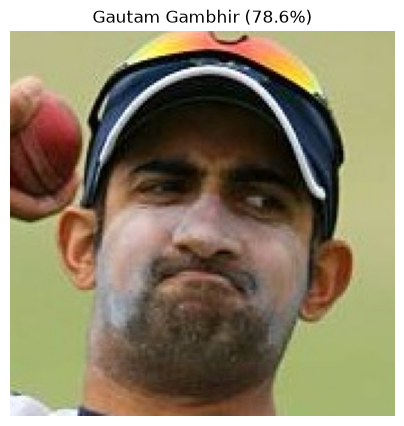

In [21]:
# ============================================================
# RUN PREDICTIONS
# ============================================================

def predict_image(image_path, model=best_model, top_k=5):
    start = time.time()
    result = model.predict(source=str(image_path), device="cpu", imgsz=IMG_SIZE, verbose=False)[0]
    elapsed = (time.time() - start) * 1000

    probs = result.probs.data.cpu().numpy()
    names = result.names
    top_idx = np.argsort(probs)[::-1][:top_k]

    print(f"Image: {image_path}")
    print(f"Predicted: {names[top_idx[0]]}  ({probs[top_idx[0]]*100:.1f}% confidence)")
    print(f"Inference time: {elapsed:.1f} ms")
    print(f"Top-{top_k}:")
    for i in top_idx:
        print(f"  {names[i]:20s} {probs[i]*100:.1f}%")

    img = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{names[top_idx[0]]} ({probs[top_idx[0]]*100:.1f}%)")
    plt.axis("off")
    plt.show()

example_dir = DATASET_DIR / "test" / CLASS_NAMES[0]
example_files = [f for f in example_dir.iterdir() if f.is_file()]
if example_files:
    predict_image(example_files[0])

In [ ]:
# ============================================================
# EXPORT MODEL (fixed)
# ============================================================

export_model = YOLO(str(MODELS_DIR / "best.pt"))
onnx_path = Path(export_model.export(format="onnx", imgsz=IMG_SIZE, device="cpu"))

dest_path = MODELS_DIR / onnx_path.name

# Only copy if the exported file isn't already in the destination folder
if onnx_path.resolve() != dest_path.resolve():
    shutil.copy2(onnx_path, dest_path)
    print(f"Copied ONNX model to: {dest_path}")
else:
    print(f"ONNX model already saved at: {dest_path}")

print("\nExport complete. Files in models/ folder:")
for f in MODELS_DIR.iterdir():
    print(f"  - {f.name}")

## Export Model

Save the model in ONNX format so it can be used outside of Python/PyTorch if needed.

In [20]:
# ============================================================
# EXPORT MODEL 
# ============================================================

export_model = YOLO(str(MODELS_DIR / "best.pt"))
onnx_path = Path(export_model.export(format="onnx", imgsz=IMG_SIZE, device="cpu"))

dest_path = MODELS_DIR / onnx_path.name

# Only copy if the exported file isn't already in the destination folder
if onnx_path.resolve() != dest_path.resolve():
    shutil.copy2(onnx_path, dest_path)
    print(f"Copied ONNX model to: {dest_path}")
else:
    print(f"ONNX model already saved at: {dest_path}")

print("\nExport complete. Files in models/ folder:")
for f in MODELS_DIR.iterdir():
    print(f"  - {f.name}")

Ultralytics 8.4.84  Python-3.13.9 torch-2.12.1+cpu CPU (12th Gen Intel Core i9-12900)
YOLO11n-cls summary (fused): 47 layers, 1,538,834 parameters, 0 gradients, 3.2 GFLOPs

PyTorch: starting from 'C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\models\best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 10) (3.1 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  0.7s, saved as 'C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\models\best.onnx' (5.9 MB)

Export complete (0.8s)
Results saved to C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\models\best.onnx
Predict:         yolo predict task=classify model=C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Pla

In [25]:
# ============================================================
# STREAMLIT APP
# ============================================================

app_code = '''
import streamlit as st
from ultralytics import YOLO
from PIL import Image
from pathlib import Path
import pandas as pd
import time

st.set_page_config(
    page_title="Cricket Player Recognition",
    layout="centered",
    initial_sidebar_state="expanded"
)

MODEL_PATH = Path(__file__).resolve().parent.parent / "models" / "best.pt"

# ---------------- Custom Styling ----------------
st.markdown("""
    <style>
    .stApp {
        background-color: #0B1220;
        color: #E6EDF7;
    }
    section[data-testid="stSidebar"] {
        background-color: #0F1A2E;
    }
    h1, h2, h3 {
        color: #F5F7FA;
    }
    .title-text {
        font-size: 2.2rem;
        font-weight: 700;
        color: #F5F7FA;
        margin-bottom: 0px;
    }
    .subtitle-text {
        color: #8FA3C4;
        font-size: 1rem;
        margin-top: 0px;
    }
    .prediction-card {
        background: linear-gradient(135deg, #1B2A4A, #14203B);
        border: 1px solid #2E4374;
        border-radius: 14px;
        padding: 24px;
        text-align: center;
        margin-top: 20px;
    }
    .predicted-name {
        font-size: 1.8rem;
        font-weight: 700;
        color: #4FA8FF;
        margin: 6px 0px;
    }
    .confidence-text {
        font-size: 1rem;
        color: #8FA3C4;
    }
    div[data-testid="stFileUploader"] {
        background-color: #101B33;
        border: 1px dashed #2E4374;
        border-radius: 12px;
        padding: 10px;
    }
    .stButton>button {
        background-color: #2E63FF;
        color: white;
        border-radius: 8px;
        border: none;
        padding: 0.5em 1.5em;
        font-weight: 600;
    }
    .stButton>button:hover {
        background-color: #1E4FE0;
        color: white;
    }
    </style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    return YOLO(str(MODEL_PATH))

model = load_model()
class_names = sorted(model.names.values())

# ---------------- Sidebar ----------------
with st.sidebar:
    st.markdown("### About")
    st.write(
        "This app identifies Indian cricketers from a photo using a "
        "YOLO11 image classification model, trained on face-cropped "
        "images for higher accuracy."
    )
    st.markdown("---")
    st.markdown("### Players in this model")
    for name in class_names:
        st.markdown(f"- {name}")
    st.markdown("---")
    st.caption("Model: YOLO11n-cls  |  Runs on CPU")

# ---------------- Header ----------------
st.markdown('<p class="title-text">Cricket Player Recognition</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle-text">Upload a photo and the model will identify the player.</p>', unsafe_allow_html=True)
st.write("")

# ---------------- Upload ----------------
uploaded_file = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    col1, col2 = st.columns([1, 1])

    image = Image.open(uploaded_file).convert("RGB")
    with col1:
        st.image(image, caption="Uploaded Image", width="stretch")

    with st.spinner("Analyzing image..."):
        start = time.time()
        result = model.predict(source=image, device="cpu", imgsz=224, verbose=False)[0]
        elapsed = (time.time() - start) * 1000

    probs = result.probs.data.cpu().numpy()
    names = result.names
    top5_idx = probs.argsort()[::-1][:5]

    top_name = names[top5_idx[0]]
    top_conf = probs[top5_idx[0]] * 100

    with col2:
        st.markdown(f"""
            <div class="prediction-card">
                <div class="confidence-text">Predicted Player</div>
                <div class="predicted-name">{top_name}</div>
                <div class="confidence-text">Confidence: {top_conf:.1f}%</div>
                <div class="confidence-text">Inference time: {elapsed:.0f} ms</div>
            </div>
        """, unsafe_allow_html=True)

    st.write("")
    st.markdown("#### Top 5 Predictions")
    df_top5 = pd.DataFrame({
        "Player": [names[i] for i in top5_idx],
        "Confidence (%)": [round(probs[i] * 100, 1) for i in top5_idx]
    }).set_index("Player")

    st.bar_chart(df_top5, color="#4FA8FF")
    st.dataframe(df_top5, use_container_width=True)

else:
    st.info("Upload a cricketer's photo to get started.")
'''

app_path = APP_DIR / "app.py"
with open(app_path, "w", encoding="utf-8") as f:
    f.write(app_code)

print(f"Streamlit app saved to: {app_path}")
print(f'\\nRun it with:\\nstreamlit run "{app_path}"')
print("\nProject complete!")

Streamlit app saved to: C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\app\app.py
\nRun it with:\nstreamlit run "C:\Users\Test1\Pictures\Cricket Player Recognition System\Cricket_Player_Recognition_System\Cricket_Player_Recognition_System\app\app.py"

Project complete!
